In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/final_dataset.csv")
df.head()

,userId,movieId,rating,title_x,genres_x,tmdbId,budget,revenue,runtime,popularity,vote_average,cast,director,writers,keywords,tag,release_year
0,1,1,4.0,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,862,30000000.0,373554033.0,81.0,21.946943,7.7,Tom Hanks Tim Allen Don Rickles Jim Varney Wal...,John Lasseter,Joss Whedon Andrew Stanton Joel Cohen,jealousy toy boy friendship friends rivalry bo...,"['pixar', 'pixar', 'fun']",1995.0
1,1,3,4.0,Grumpier Old Men,Comedy|Romance,15602,NaN,NaN,101.0,11.712900,6.5,Walter Matthau Jack Lemmon Ann-Margret Sophia ...,Howard Deutch,Mark Steven Johnson Mark Steven Johnson,fishing best_friend duringcreditsstinger old_men,"['moldy', 'old']",1995.0
2,1,6,4.0,Heat,Action|Crime|Thriller,949,60000000.0,187436818.0,170.0,17.924927,7.7,Al Pacino Robert De Niro Val Kilmer Jon Voight...,Michael Mann,Michael Mann,robbery detective bank obsession chase shootin...,NaN,1995.0
3,1,47,5.0,Seven (a.k.a. Se7en),Mystery|Thriller,807,33000000.0,327311859.0,127.0,18.457430,8.1,Brad Pitt Morgan Freeman Gwyneth Paltrow John ...,David Fincher,Andrew Kevin Walker,self-fulfilling_prophecy detective s.w.a.t. dr...,"['mystery', 'twist ending', 'serial killer']",1995.0
4,1,50,5.0,"Usual Suspects, The",Crime|Mystery|Thriller,629,6000000.0,23341568.0,106.0,16.302466,8.1,Stephen Baldwin Gabriel Byrne Chazz Palminteri...,Bryan Singer,Christopher McQuarrie John Coven,law relatives theft criminal criminal_mastermi...,"['mindfuck', 'suspense', 'thriller', 'tricky',...",1995.0


In [3]:
df.shape

(100823, 17)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = df.drop(columns=["rating"])
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
print(X_train.shape)
print(X_test.shape)

(80658, 16)
(20165, 16)


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD

user_item_matrix = df.pivot(index='userId', columns='movieId', values='rating').fillna(0)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [7]:
# --- MODEL 1: KNN (K-Nearest Neighbors) ---
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(user_item_matrix.values)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [8]:
import numpy as np

matrix_values = user_item_matrix.values
user_item_matrix_filled = user_item_matrix.copy()

user_index_map = {u: i for i, u in enumerate(user_item_matrix.index)}
movie_index_map = {m: i for i, m in enumerate(user_item_matrix.columns)}


distances, indices = knn_model.kneighbors(
    matrix_values,
    n_neighbors=5
)

# usuwamy samego siebie (pierwszy sąsiad to zawsze user)
neighbors_matrix = indices[:, 1:]


# === 3. Funkcja predykcji ===

def predict_knn_fast(u_id, m_id):
    # fallback jeśli brak usera lub filmu
    if u_id not in user_index_map or m_id not in movie_index_map:
        return 3.0

    u_idx = user_index_map[u_id]
    m_idx = movie_index_map[m_id]

    # pobierz sąsiadów
    neighbors = neighbors_matrix[u_idx]

    # ratingi sąsiadów dla danego filmu
    ratings = matrix_values[neighbors, m_idx]

    # filtrujemy tylko ocenione
    ratings = ratings[ratings > 0]

    if ratings.size > 0:
        return ratings.mean()

    # fallback: średnia usera
    user_ratings = matrix_values[u_idx]
    user_ratings = user_ratings[user_ratings > 0]

    if user_ratings.size > 0:
        return user_ratings.mean()

    return 3.0


# === 4. Predykcja dla test_df ===

knn_results = [
    predict_knn_fast(row.userId, row.movieId)
    for row in test_df.itertuples(index=False)
]

knn_results = np.array(knn_results)

In [9]:
# --- MODEL 2: SVD (Matrix Factorization) ---
user_means = pd.Series(
    np.where((matrix_values > 0).sum(axis=1) > 0,
             matrix_values.sum(axis=1) / (matrix_values > 0).sum(axis=1),
             0),
    index=user_item_matrix.index
)

# centrowanie
matrix_centered = user_item_matrix_filled.replace(0, np.nan)
matrix_centered = matrix_centered.sub(user_means, axis=0).fillna(0)

# SVD
svd = TruncatedSVD(n_components=50, random_state=42)
latent = svd.fit_transform(matrix_centered)

reconstructed = np.dot(latent, svd.components_)

# dodanie biasu użytkownika
reconstructed = reconstructed + user_means.values.reshape(-1, 1)

svd_preds_df = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)


def predict_svd(u_id, m_id):
    if u_id in svd_preds_df.index and m_id in svd_preds_df.columns:
        pred = svd_preds_df.loc[u_id, m_id]
        return np.clip(pred, 1, 5)
    return 3.0


svd_results = [
    predict_svd(row.userId, row.movieId)
    for row in test_df.itertuples(index=False)
]

In [11]:
knn_rmse = np.sqrt(mean_squared_error(test_df['rating'], knn_results))
svd_rmse = np.sqrt(mean_squared_error(test_df['rating'], svd_results))

results_summary = pd.DataFrame({
    'Algorytm': ['KNN', 'SVD'],
    'RMSE (Błąd)': [knn_rmse, svd_rmse]
})

print("\n--- PORÓWNANIE WYNIKÓW ---")
print(results_summary.to_markdown(index=False))


--- PORÓWNANIE WYNIKÓW ---
| Algorytm   |   RMSE (Błąd) |
|:-----------|--------------:|
| KNN        |      1.04062  |
| SVD        |      0.618912 |


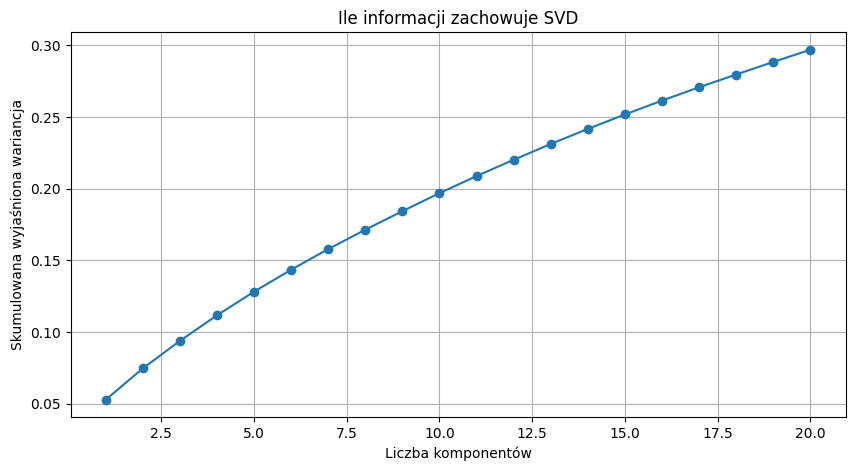

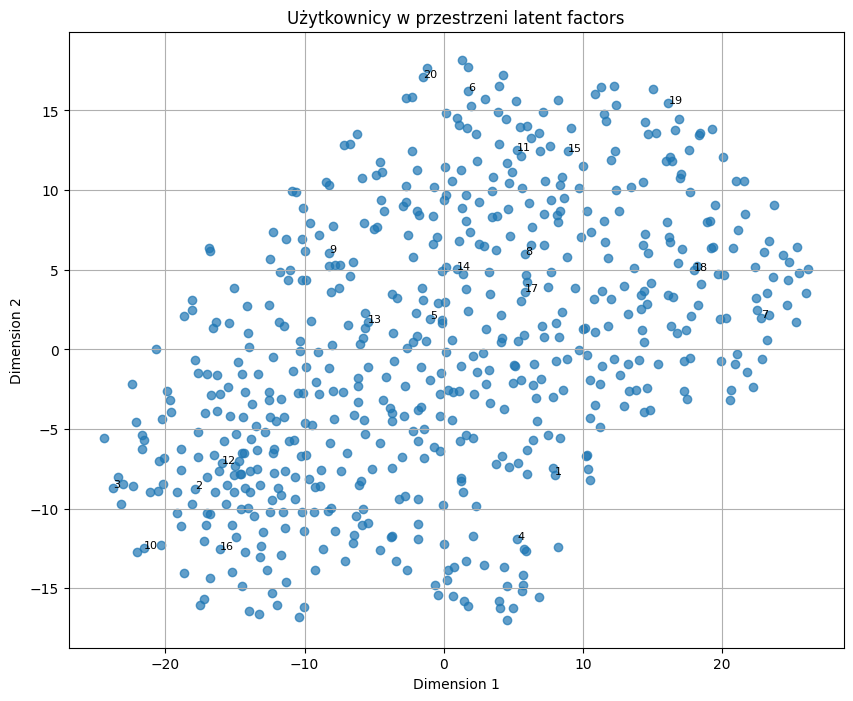

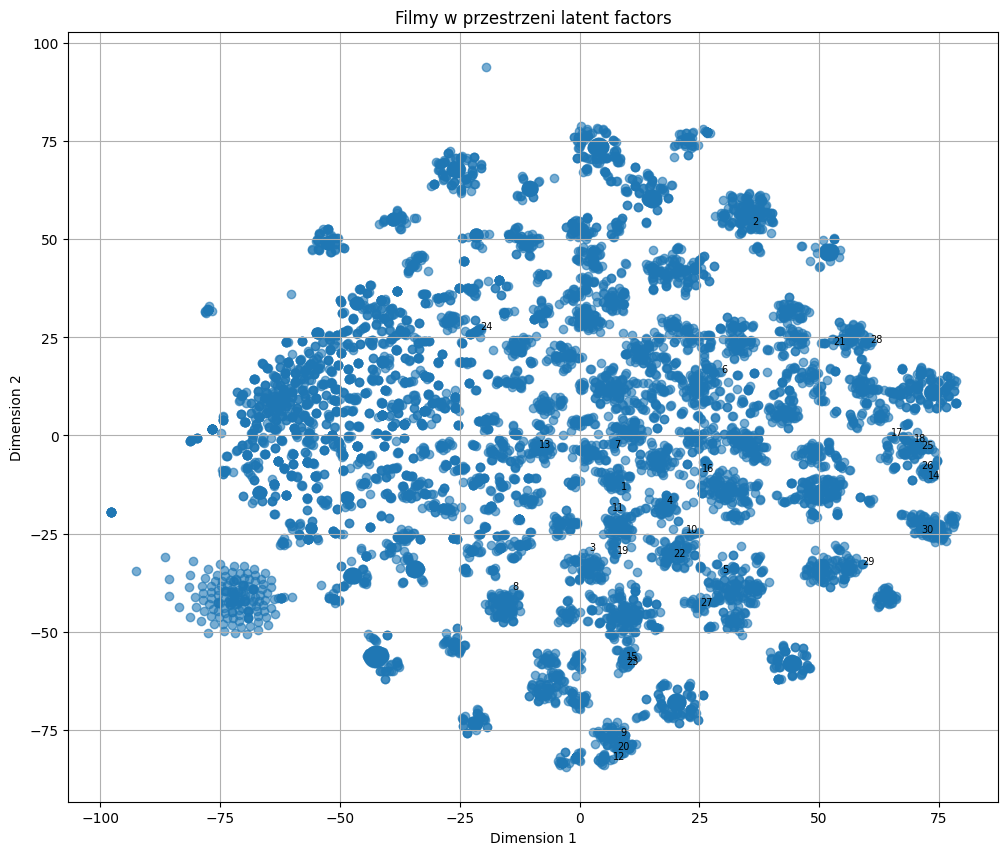


Najbardziej podobni użytkownicy do 1:

User 457 | similarity = 0.815
User 135 | similarity = 0.803
User 312 | similarity = 0.762
User 302 | similarity = 0.759
User 57 | similarity = 0.747

Top rekomendacje dla użytkownika 1:

movieId
858     4.659635
318     4.646806
32      4.585367
541     4.561168
778     4.560107
1221    4.548332
1288    4.537698
1199    4.528443
7153    4.528401
924     4.523468
Name: 1, dtype: float64


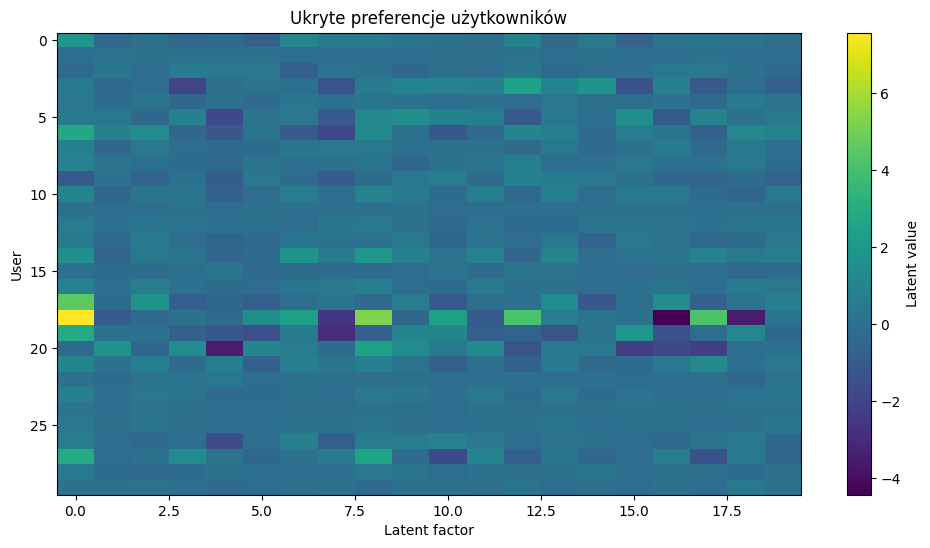

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# ================================
# 1. TRENING SVD
# ================================

# średnie użytkowników
user_means = pd.Series(
    np.where((matrix_values > 0).sum(axis=1) > 0,
             matrix_values.sum(axis=1) / (matrix_values > 0).sum(axis=1),
             0),
    index=user_item_matrix.index
)

# centrowanie
matrix_centered = user_item_matrix.replace(0, np.nan)
matrix_centered = matrix_centered.sub(user_means, axis=0).fillna(0)

# SVD
svd = TruncatedSVD(n_components=20, random_state=42)

user_latent = svd.fit_transform(matrix_centered)
movie_latent = svd.components_.T

# ================================
# 2. WYJAŚNIENIE WARIANCJI
# ================================

explained = svd.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker='o')
plt.xlabel("Liczba komponentów")
plt.ylabel("Skumulowana wyjaśniona wariancja")
plt.title("Ile informacji zachowuje SVD")
plt.grid(True)
plt.show()

# ================================
# 3. WIZUALIZACJA UŻYTKOWNIKÓW
# ================================

# redukcja do 2D
tsne_users = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

users_2d = tsne_users.fit_transform(user_latent)

plt.figure(figsize=(10, 8))

plt.scatter(
    users_2d[:, 0],
    users_2d[:, 1],
    alpha=0.7
)

plt.title("Użytkownicy w przestrzeni latent factors")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

# podpisz kilku użytkowników
for i, user_id in enumerate(user_item_matrix.index[:20]):
    plt.annotate(
        str(user_id),
        (users_2d[i, 0], users_2d[i, 1]),
        fontsize=8
    )

plt.grid(True)
plt.show()

# ================================
# 4. WIZUALIZACJA FILMÓW
# ================================

tsne_movies = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

movies_2d = tsne_movies.fit_transform(movie_latent)

plt.figure(figsize=(12, 10))

plt.scatter(
    movies_2d[:, 0],
    movies_2d[:, 1],
    alpha=0.6
)

plt.title("Filmy w przestrzeni latent factors")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

# podpisz kilka filmów
movie_names = list(user_item_matrix.columns[:30])

for i, movie_id in enumerate(movie_names):
    plt.annotate(
        str(movie_id),
        (movies_2d[i, 0], movies_2d[i, 1]),
        fontsize=7
    )

plt.grid(True)
plt.show()

# ================================
# 5. PODOBNI UŻYTKOWNICY
# ================================

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(user_latent)

target_user = 0

sim_scores = similarity[target_user]

closest = np.argsort(sim_scores)[::-1][1:6]

print(f"\nNajbardziej podobni użytkownicy do {user_item_matrix.index[target_user]}:\n")

for idx in closest:
    print(
        f"User {user_item_matrix.index[idx]} "
        f"| similarity = {sim_scores[idx]:.3f}"
    )

# ================================
# 6. REKONSTRUKCJA OCEN
# ================================

reconstructed = np.dot(user_latent, svd.components_)
reconstructed += user_means.values.reshape(-1, 1)

reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

# pokaż rekomendacje dla jednego usera
example_user = user_item_matrix.index[0]

real_ratings = user_item_matrix.loc[example_user]
predicted = reconstructed_df.loc[example_user]

unseen_movies = real_ratings[real_ratings == 0].index

recommendations = (
    predicted[unseen_movies]
    .sort_values(ascending=False)
    .head(10)
)

print(f"\nTop rekomendacje dla użytkownika {example_user}:\n")
print(recommendations)

# ================================
# 7. HEATMAPA LATENT FACTORS
# ================================

plt.figure(figsize=(12, 6))

plt.imshow(
    user_latent[:30],
    aspect='auto'
)

plt.colorbar(label='Latent value')

plt.xlabel("Latent factor")
plt.ylabel("User")

plt.title("Ukryte preferencje użytkowników")

plt.show()

In [14]:
print(user_item_matrix)

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     0.0     4.0     0.0     0.0     4.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
...         ...     ...     ...     ...     ...     ...     ...     ...   
606         2.5     0.0     0.0     0.0     0.0     0.0     2.5     0.0   
607         4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
608         2.5     2.0     2.0     0.0     0.0     0.0     0.0     0.0   
609         3.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
610         5.0     0.0     0.0     0.0     0.0     5.0     0.0     0.0   

movieId  9       10     